# **MPII 데이터셋 다운로드하기**

In [ ]:
# 프로젝트 폴더 생성
!mkdir -p /content/pose_estimation/mpii

# MPII 데이터 다운로드
!wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz -P /content/pose_estimation/mpii
!wget https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip -P /content/pose_estimation/mpii

# 압축 해제
!tar -xf /content/pose_estimation/mpii/mpii_human_pose_v1.tar.gz -C /content/pose_estimation/mpii
!unzip -q /content/pose_estimation/mpii/mpii_human_pose_v1_u12_2.zip -d /content/pose_estimation/mpii

--2026-09-04 09:35:47--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12088943206 (11G) [application/x-gzip]
Saving to: ‘/content/pose_estimation/mpii/mpii_human_pose_v1.tar.gz’

mpii_human_pose_v1. 100%[===================>]  11.26G  7.58MB/s    in 12m 24s 

2026-09-04 09:48:12 (15.5 MB/s) - ‘/content/pose_estimation/mpii/mpii_human_pose_v1.tar.gz’ saved [12088943206/12088943206]

--2026-09-04 09:48:12--  https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip
Resolving datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)... 139.19.206.177
Connecting to datasets.d2.mpi-inf.mpg.de (datasets.d2.mpi-inf.mpg.de)|139.19.206.177|:443... connected.
HTTP request sent, awaiting response... 200 OK


`mpii_human_pose_v1_u12_2.zip` 을 풀어보면 `mpii_human_pose_v1_u12_1.mat` 파일이 나와서 열어보기 불편한데요. 파이썬에서 읽기 쉽도록 json 파일로 변환해 두었습니다.

In [ ]:
# JSON 파일 다운로드
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/train.json -P /content/pose_estimation/mpii/mpii_human_pose_v1_u12_2

!wget https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json -P /content/pose_estimation/mpii/mpii_human_pose_v1_u12_2

--2026-09-04 09:50:47--  https://d3s0tskafalll9.cloudfront.net/media/documents/train.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.95, 13.249.182.60, 13.249.182.118, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13.249.182.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31043010 (30M) [application/json]
Saving to: ‘/content/pose_estimation/mpii/mpii_human_pose_v1_u12_2/train.json’

train.json          100%[===================>]  29.60M   114MB/s    in 0.3s    

2026-09-04 09:50:47 (114 MB/s) - ‘/content/pose_estimation/mpii/mpii_human_pose_v1_u12_2/train.json’ saved [31043010/31043010]

--2026-09-04 09:50:47--  https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.95, 13.249.182.60, 13.249.182.118, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13

In [ ]:
# !wget https://d3s0tskafalll9.cloudfront.net/media/documents/mpii_gtuV0hd.zip -O mpii.zip

# !mkdir -p /content/pose_estimation/mpii

# !unzip mpii.zip -d /content/pose_estimation/mpii

# **데이터 전처리하기**



```
PROJECT_PATH
/content/aiffel/mpii

IMAGE_PATH
/content/aiffel/mpii/images

MODEL_PATH
/content/aiffel/mpii/models

PT_RECORD_PATH
/content/aiffel/mpii/ptrecords_mpii

TRAIN_JSON
/content/aiffel/mpii/mpii_human_pose_v1_u12_2/train.json

VALID_JSON
/content/aiffel/mpii/mpii_human_pose_v1_u12_2/validation.json
```



In [ ]:
import os

PROJECT_PATH = '/content/pose_estimation/mpii'

IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')

TRAIN_JSON = os.path.join(
    PROJECT_PATH,
    'mpii_human_pose_v1_u12_2',
    'train.json'
)

VALID_JSON = os.path.join(
    PROJECT_PATH,
    'mpii_human_pose_v1_u12_2',
    'validation.json'
)

# **json 파싱하기**

json이 어떻게 구성되어 있는지 파악해 보기 위해 json 파일을 열어 샘플로 annotation 정보를 1개만 출력

In [ ]:
import json

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


| 항목           | 의미                  | 예시               |
| ------------ | ------------------- | ---------------- |
| `joints_vis` | 각 관절이 보이는지 여부       | `1`              |
| `joints`     | 16개 관절의 `(x, y)` 좌표 | `[620.0, 394.0]` |
| `image`      | 대상 이미지 파일명          | `015601864.jpg`  |
| `scale`      | 사람의 크기/영역을 나타내는 스케일 | `3.021046`       |
| `center`     | 사람 영역의 중심 좌표        | `[594.0, 257.0]` |


| 번호 | 관절      |
| -: | ------- |
|  0 | 오른쪽 발목  |
|  1 | 오른쪽 무릎  |
|  2 | 오른쪽 엉덩이 |
|  3 | 왼쪽 엉덩이  |
|  4 | 왼쪽 무릎   |
|  5 | 왼쪽 발목   |
|  6 | 골반      |
|  7 | 흉부      |
|  8 | 목       |
|  9 | 머리 위    |
| 10 | 오른쪽 손목  |
| 11 | 오른쪽 팔꿈치 |
| 12 | 오른쪽 어깨  |
| 13 | 왼쪽 어깨   |
| 14 | 왼쪽 팔꿈치  |
| 15 | 왼쪽 손목   |

json annotation 을 파싱하는 함수

In [ ]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation


with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': '/content/pose_estimation/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


# **DataLoader 파일 만들기**

Input(사람 이미지) -> Output(관절 heatmap)

In [ ]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

# **Ray**

앞서 작성한 함수를 사용해 데이터를 `.pt` 파일로 변환합니다.

train 데이터는 64개 파일로, val 데이터는 8개 파일로 저장

In [ ]:
os.makedirs(os.path.join(PT_RECORD_PATH, 'train'), exist_ok=True)
os.makedirs(os.path.join(PT_RECORD_PATH, 'val'), exist_ok=True)

# **data label 로 만들기**

In [ ]:
!pip install tfrecord

In [ ]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

사람의 Keypoint 위치를 기준으로 이미지에서 사람 부분만 잘라내는(ROI Crop) 전처리 함수

In [ ]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

정답(Label)으로 사용할 Keypoint Heatmap을 만드는 함수(가우시안 분포 사용)

In [ ]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps



```
MPIIDataset
    │
    │  image + annotation
    ▼
Preprocessor.__call__()
    │
    ├─ ① annotation을 features 형태로 변환
    │
    ├─ ② 사람 영역 crop
    │      └─ keypoint 좌표도 crop 기준으로 재계산
    │
    ├─ ③ 이미지를 256×256으로 resize
    │
    ├─ ④ 이미지 값을 [-1, 1]로 정규화
    │
    └─ ⑤ keypoint 좌표 → 64×64 Gaussian heatmap 16장
             │
             ▼
       image_tensor
       heatmaps
```



In [ ]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_visibility가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_visibility', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

# **Hourglass 모델**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

In [ ]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x



```
입력 이미지
  (B, 3, 256, 256)
        │
        ▼
   7×7 Conv, stride=2
        │
        ▼
   Bottleneck 64 → 128
        │
        ▼
      MaxPool
        │
        ▼
   Bottleneck 128 → 128
        │
        ▼
   Bottleneck 128 → 256
        │
        ▼
   ┌───────────────────────┐
   │   Hourglass #1        │
   │   ↓                    │
   │   Residual             │
   │   ↓                    │
   │   Linear 1×1           │
   │   ↓                    │
   │   Heatmap 16장         │
   └───────────────────────┘
        │
        │ intermediate feature
        ▼
   ┌───────────────────────┐
   │   Hourglass #2        │
   │   ↓                    │
   │   Residual             │
   │   ↓                    │
   │   Linear               │
   │   ↓                    │
   │   Heatmap 16장         │
   └───────────────────────┘
        │
       ...
        │
        ▼
   ┌───────────────────────┐
   │   Hourglass #4        │
   │   ↓                    │
   │   Residual             │
   │   ↓                    │
   │   Linear               │
   │   ↓                    │
   │   Heatmap 16장         │
   └───────────────────────┘

최종:
outputs = [heatmap1, heatmap2, heatmap3, heatmap4]
```



In [ ]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

# **학습 엔진**



```
MPIIDataset
    ↓
DataLoader
    ↓
(images, GT heatmaps)
    ↓
Trainer.train_step()
    ↓
StackedHourglassNetwork
    ↓
4개의 heatmap
    ↓
weighted MSE loss
    ↓
backpropagation
    ↓
Adam
    ↓
모델 업데이트
```



In [ ]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # epoch별 train/validation loss 저장
        self.train_losses = []
        self.val_losses = []

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """

        # SimpleBaseline처럼 Tensor 하나를 출력하는 경우
        if torch.is_tensor(outputs):
            outputs = [outputs]

        # Stacked Hourglass처럼
        # 여러 개의 heatmap을 list로 출력하는 경우
        # 그대로 사용

        loss = 0.0
        weights = (labels > 0).float() * 81 + 1

        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            loss += weighted_error.mean()

        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                      f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)

                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                    num_val_batches += 1
                else:
                    print(f"[Val] batch {num_val_batches + 1} loss NaN → 제외")

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # epoch별 loss 저장
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

        return self.best_model

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

In [ ]:
from torch.utils.data import DataLoader

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    transform = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )
    dataset = MPIIDataset(
        annotation_file=annotation_file,
        image_dir=image_dir,
        transform=transform
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=is_train)

In [ ]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print("Start training...")
    return trainer.run(train_loader, val_loader, device)

# **예측 엔진 만들기**

In [ ]:
# import gdown
# import os
# import torch

# file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
# output_path = "model-epoch-2-loss-1.2050.pt"

# gdown.download(
#     f"https://drive.google.com/uc?id={file_id}",
#     output_path,
#     quiet=False
# )

# # 기존 PROJECT_PATH에 맞는 위치로 이동
# !mv model-epoch-2-loss-1.2050.pt /content/pose_estimation/mpii/models/

In [ ]:
# epochs = 2
# batch_size = 16
# num_heatmap = 16
# learning_rate = 0.0007

# WEIGHTS_PATH = os.path.join(
#     PROJECT_PATH,
#     'models',
#     'model-epoch-2-loss-1.2050.pt'
# )

# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )

# model = StackedHourglassNetwork(
#     IMAGE_SHAPE,
#     num_stack=4,
#     num_residual=1,
#     num_heatmap=num_heatmap
# )

# model.to(device)

# checkpoint = torch.load(
#     WEIGHTS_PATH,
#     map_location=device,
#     weights_only=False
# )

# model.load_state_dict(checkpoint)
# model.eval()

In [ ]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

heatmap에서 최대값을 찾는 함수

In [ ]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    y = indices // W
    x = indices - W * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)

위 함수만으로는 256x256 이미지에 64x64 heatmap max 값을 표현할 때 quantization 오차가 발생하기 때문에 실제 계산에서는 3x3 필터를 이용해서 근사치를 구해줍니다.

In [ ]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

In [ ]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

In [ ]:
! wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" -O test_image.jpg
! mv test_image.jpg /content/pose_estimation/mpii/

--2026-09-04 10:46:48--  https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058994 (1.0M) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]   1.01M  --.-KB/s    in 0.04s   

2026-09-04 10:46:48 (28.6 MB/s) - ‘test_image.jpg’ saved [1058994/1058994]



# **simplebaseline**

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights


class DeconvBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super(DeconvBlock, self).__init__()

        self.deconv = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=4,
            stride=2,
            padding=1,
            bias=False
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.deconv(x)
        x = self.bn(x)
        x = self.relu(x)

        return x


class SimpleBaseline(nn.Module):

    def __init__(
        self,
        num_heatmap=16,
        pretrained=False
    ):
        super(SimpleBaseline, self).__init__()

        # ==========================================
        # ResNet50 Backbone
        # ==========================================

        if pretrained:
            weights = ResNet50_Weights.DEFAULT
        else:
            weights = None

        resnet = resnet50(weights=weights)

        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,

            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
            resnet.layer4
        )

        # ResNet50 layer4 output
        # (B, 2048, 8, 8)
        #
        # 입력 256×256 기준:
        #
        # 256
        # ↓ conv1 stride 2
        # 128
        # ↓ maxpool stride 2
        # 64
        # ↓ layer2
        # 32
        # ↓ layer3
        # 16
        # ↓ layer4
        # 8

        # ==========================================
        # Deconvolution Head
        # ==========================================

        self.deconv_layers = nn.Sequential(

            DeconvBlock(
                2048,
                256
            ),

            DeconvBlock(
                256,
                256
            ),

            DeconvBlock(
                256,
                256
            )
        )

        # 8 → 16 → 32 → 64
        #
        # 결과:
        # (B, 256, 64, 64)

        # ==========================================
        # Heatmap Head
        # ==========================================

        self.final_layer = nn.Conv2d(
            256,
            num_heatmap,
            kernel_size=1,
            stride=1,
            padding=0
        )

        self._init_weights()

    def _init_weights(self):

        for m in self.deconv_layers.modules():

            if isinstance(m, nn.ConvTranspose2d):

                nn.init.normal_(
                    m.weight,
                    mean=0,
                    std=0.001
                )

            elif isinstance(m, nn.BatchNorm2d):

                nn.init.constant_(
                    m.weight,
                    1
                )

                nn.init.constant_(
                    m.bias,
                    0
                )

        nn.init.normal_(
            self.final_layer.weight,
            mean=0,
            std=0.001
        )

        if self.final_layer.bias is not None:
            nn.init.constant_(
                self.final_layer.bias,
                0
            )

    def forward(self, x):

        # ==========================================
        # Backbone
        # ==========================================

        x = self.backbone(x)

        # (B, 3, 256, 256)
        #          ↓
        # (B, 2048, 8, 8)

        # ==========================================
        # Deconvolution
        # ==========================================

        x = self.deconv_layers(x)

        # (B, 2048, 8, 8)
        #          ↓
        # (B, 256, 64, 64)

        # ==========================================
        # Heatmap
        # ==========================================

        x = self.final_layer(x)

        # (B, 256, 64, 64)
        #          ↓
        # (B, 16, 64, 64)

        return x

In [ ]:
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # skip connection branch (해상도 유지)
        self.up1 = nn.Sequential(*[
            BottleneckBlock(filters, filters) for _ in range(num_residual)
        ])

        # down-sampling branch
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1 = nn.Sequential(*[
            BottleneckBlock(filters, filters) for _ in range(num_residual)
        ])

        # order가 1보다 크면 재귀적으로 다음 단계 Hourglass, 아니면 residual block으로 종료
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2 = nn.Sequential(*[
                BottleneckBlock(filters, filters) for _ in range(num_residual)
            ])

        self.low3 = nn.Sequential(*[
            BottleneckBlock(filters, filters) for _ in range(num_residual)
        ])

        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        up1 = self.up1(x)          # skip connection (원래 해상도)

        pool = self.pool(x)
        low1 = self.low1(pool)
        low2 = self.low2(low1)     # 재귀 호출 또는 residual block
        low3 = self.low3(low2)
        up2 = self.upsample(low3)  # 원래 해상도로 복원

        return up1 + up2

In [ ]:
if not os.path.exists(MODEL_PATH):
    os.makedirs(MODEL_PATH)

# 공통 설정
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 1e-3
NUM_HEATMAP = 16

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# DataLoader
train_loader = create_dataloader(
    annotation_file=TRAIN_JSON,
    image_dir=IMAGE_PATH,
    batch_size=BATCH_SIZE,
    num_heatmap=NUM_HEATMAP,
    is_train=True
)

val_loader = create_dataloader(
    annotation_file=VALID_JSON,
    image_dir=IMAGE_PATH,
    batch_size=BATCH_SIZE,
    num_heatmap=NUM_HEATMAP,
    is_train=False
)


# 1. Hourglass 학습
print("1. Stacked Hourglass Training")

hourglass_model = StackedHourglassNetwork(
    IMAGE_SHAPE,
    num_stack=4,
    num_residual=1,
    num_heatmap=NUM_HEATMAP
).to(device)

hourglass_trainer = Trainer(
    model=hourglass_model,
    epochs=EPOCHS,
    global_batch_size=BATCH_SIZE,
    initial_learning_rate=LEARNING_RATE
)

hourglass_best_model = hourglass_trainer.run(
    train_loader,
    val_loader,
    device
)

print("Hourglass Best Model:", hourglass_best_model)


# 2. SimpleBaseline 학습
print("\n")
print("=" * 60)
print("2. SimpleBaseline Training")

simplebaseline_model = SimpleBaseline(
    num_heatmap=NUM_HEATMAP,
    pretrained=False
).to(device)

simplebaseline_trainer = Trainer(
    model=simplebaseline_model,
    epochs=EPOCHS,
    global_batch_size=BATCH_SIZE,
    initial_learning_rate=LEARNING_RATE
)

simplebaseline_best_model = simplebaseline_trainer.run(
    train_loader,
    val_loader,
    device
)

print("SimpleBaseline Best Model:", simplebaseline_best_model)

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[Train] batch 587 loss 18.9244 avg_loss 18.9948
[Train] batch 588 loss 19.0261 avg_loss 18.9949
[Train] batch 589 loss 19.2167 avg_loss 18.9953
[Train] batch 590 loss 18.7621 avg_loss 18.9949
[Train] batch 591 loss 18.8627 avg_loss 18.9946
[Train] batch 592 loss 19.6446 avg_loss 18.9957
[Train] batch 593 loss 20.1535 avg_loss 18.9977
[Train] batch 594 loss 17.9672 avg_loss 18.9960
[Train] batch 595 loss 20.2875 avg_loss 18.9981
[Train] batch 596 loss 18.7664 avg_loss 18.9977
[Train] batch 597 loss 17.8534 avg_loss 18.9958
[Train] batch 598 loss 18.1497 avg_loss 18.9944
[Train] batch 599 loss 19.9832 avg_loss 18.9961
[Train] batch 600 loss 17.5083 avg_loss 18.9936
[Train] batch 601 loss 18.9064 avg_loss 18.9934
[Train] batch 602 loss 19.4902 avg_loss 18.9943
[Train] batch 603 loss 18.7417 avg_loss 18.9938
[Train] batch 604 loss 18.0718 avg_loss 18.9923
[Train] batch 605 loss 19.8214 avg_loss 18.9937
[Train] batch 606 loss 20.4451 avg_loss 18.9961
[Tra

총 2시간 20분 소요 -> 에폭 당 평균 23분 소요

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Epoch": [1, 2, 3],
    "Hourglass Val Loss": hourglass_trainer.val_losses,
    "SimpleBaseline Val Loss": simplebaseline_trainer.val_losses
})

comparison

,Epoch,Hourglass Val Loss,SimpleBaseline Val Loss
0,1,20.125883,5.499103
1,2,19.113733,5.120863
2,3,18.744317,4.945449


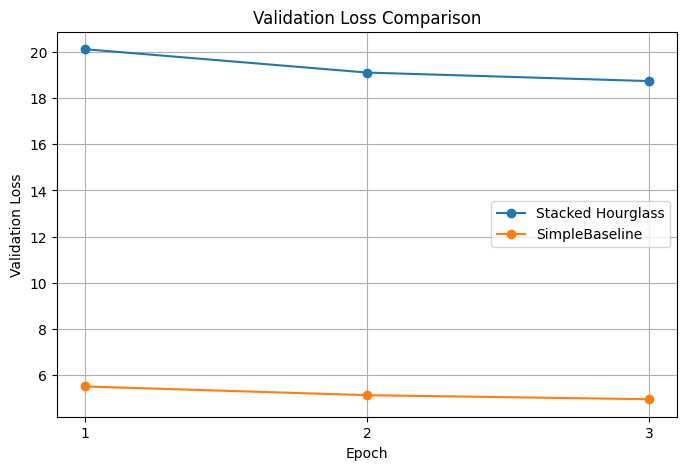

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

epochs = range(1, EPOCHS + 1)

plt.plot(
    epochs,
    hourglass_trainer.val_losses,
    marker='o',
    label='Stacked Hourglass'
)

plt.plot(
    epochs,
    simplebaseline_trainer.val_losses,
    marker='o',
    label='SimpleBaseline'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Validation Loss Comparison')

plt.xticks(list(epochs))
plt.legend()
plt.grid(True)

plt.show()

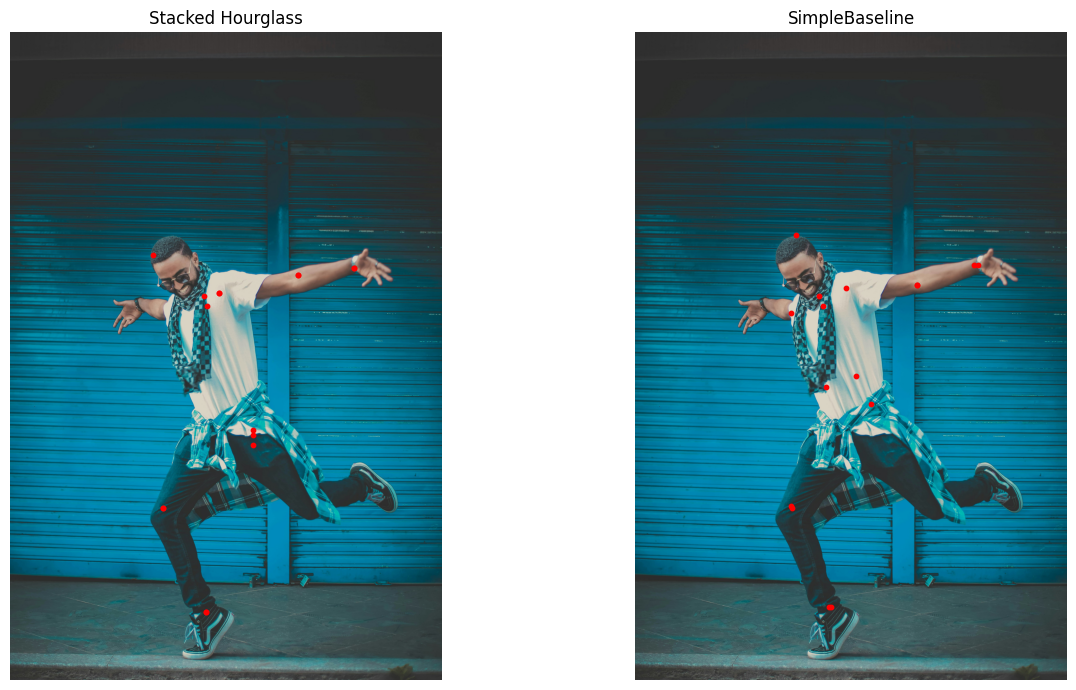

In [ ]:
import os
import matplotlib.pyplot as plt

test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

# Stacked Hourglass 예측
hourglass_image, hourglass_keypoints = predict(
    hourglass_model,
    test_image
)

# SimpleBaseline 예측
simplebaseline_image, simplebaseline_keypoints = predict(
    simplebaseline_model,
    test_image
)


# 두 모델의 keypoint 결과 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Stacked Hourglass
axes[0].imshow(to_numpy_image(hourglass_image))

for i, joint in enumerate(hourglass_keypoints):
    joint_x = joint[0] * hourglass_image.width
    joint_y = joint[1] * hourglass_image.height
    axes[0].scatter(joint_x, joint_y, s=10, c='red', marker='o')

axes[0].set_title("Stacked Hourglass")
axes[0].axis("off")


# SimpleBaseline
axes[1].imshow(to_numpy_image(simplebaseline_image))

for i, joint in enumerate(simplebaseline_keypoints):
    joint_x = joint[0] * simplebaseline_image.width
    joint_y = joint[1] * simplebaseline_image.height
    axes[1].scatter(joint_x, joint_y, s=10, c='red', marker='o')

axes[1].set_title("SimpleBaseline")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torch

MPII_JOINT_NAMES = [
    'R_Ankle', 'R_Knee', 'R_Hip', 'L_Hip', 'L_Knee', 'L_Ankle',
    'Pelvis', 'Thorax', 'Upper_Neck', 'Head_Top',
    'R_Wrist', 'R_Elbow', 'R_Shoulder', 'L_Shoulder', 'L_Elbow', 'L_Wrist'
]

def compute_pck(model, val_loader, device, threshold=0.05):
    """
    threshold: 정규화된 좌표(0~1) 기준 허용 거리 (예: 0.05 = 이미지 크기의 5%)
    """
    model.eval()
    num_joints = len(MPII_JOINT_NAMES)
    correct = torch.zeros(num_joints)
    total = torch.zeros(num_joints)

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)

            # 여러 스택 출력이면 마지막 것 사용
            if isinstance(outputs, list):
                outputs = outputs[-1]

            batch_size = images.shape[0]
            for b in range(batch_size):
                # (num_heatmap, H, W) -> (H, W, num_heatmap)
                pred_heatmap = outputs[b].permute(1, 2, 0).detach().cpu()
                gt_heatmap = labels[b].permute(1, 2, 0).detach().cpu() \
                    if labels[b].shape[0] == num_joints else labels[b].cpu()

                pred_kp = extract_keypoints_from_heatmap(pred_heatmap)
                gt_kp = extract_keypoints_from_heatmap(gt_heatmap)

                dist = torch.norm(pred_kp - gt_kp, dim=1)  # (num_joints,)
                correct += (dist < threshold).float()
                total += 1

    pck_per_joint = correct / total
    pck_overall = correct.sum() / total.sum()

    return pck_per_joint, pck_overall.item()

In [ ]:
threshold = 0.05  # 필요시 조정 (0.05 = 이미지 크기의 5% 이내면 정답으로 간주)

hourglass_pck_per_joint, hourglass_pck = compute_pck(hourglass_model, val_loader, device, threshold)
simplebaseline_pck_per_joint, simplebaseline_pck = compute_pck(simplebaseline_model, val_loader, device, threshold)

print(f"Hourglass PCK@{threshold}: {hourglass_pck:.4f}")
print(f"SimpleBaseline PCK@{threshold}: {simplebaseline_pck:.4f}")

pck_comparison = pd.DataFrame({
    "Joint": MPII_JOINT_NAMES,
    "Hourglass PCK": hourglass_pck_per_joint.numpy(),
    "SimpleBaseline PCK": simplebaseline_pck_per_joint.numpy()
})

pck_comparison

Hourglass PCK@0.05: 0.5255
SimpleBaseline PCK@0.05: 0.4245


,Joint,Hourglass PCK,SimpleBaseline PCK
0,R_Ankle,0.302231,0.254902
1,R_Knee,0.358012,0.311359
2,R_Hip,0.443543,0.346518
3,L_Hip,0.421569,0.303584
4,L_Knee,0.364435,0.288032
5,L_Ankle,0.320487,0.266058
6,Pelvis,0.582150,0.519270
7,Thorax,0.845504,0.797836
8,Upper_Neck,0.866126,0.799189
9,Head_Top,0.770791,0.736984


# 결과 해석

### Validation Loss
- SimpleBaseline의 loss(4.9 ~ 5.5)가 Hourglass의 loss(18.7 ~ 20.1)보다 훨씬 낮게 나왔지만 직접 비교는 무의미합니다. Hourglass는 4개 스택 각각의 heatmap에 대해 loss를 합산(`loss += ...`)하는 반면에 SimpleBaseline은 출력이 1개뿐이라 애초에 loss 스케일 자체가 다릅니다.
- 두 모델 모두 3 에폭 동안 loss가 조금씩 감소하는 추세라 아직 수렴 전 단계이지만 시간 상 3 에폭만 수행하였습니다.

### PCK@0.05
- **전체 PCK: Hourglass 0.526 > SimpleBaseline 0.425**로 Hourglass가 더 정확합니다.
- 관절별로 봐도 **16개 전 관절에서 Hourglass가 SimpleBaseline을 앞섭니다.**
- 격차가 큰 부위: 손목/팔꿈치(R_Wrist +0.15, R_Elbow +0.16), 고관절(R_Hip +0.10)
- 상대적으로 격차가 작은 부위: Thorax, Upper_Neck, Head_Top -> 몸통·머리처럼 크고 위치가 안정적인 관절은 두 모델 다 잘 맞춤
- 공통적으로 어려운 부위: 발목(R/L_Ankle)이 두 모델 다 최하위권 -> 다리 끝부분이 가장 어려운 것으로 보임

### 정성적 결과
- 육안으로는 두 모델 다 대략적인 자세를 잘 잡아내며 이 한 장의 예시만으로는 PCK 수치만큼 뚜렷한 차이가 보이지 않습니다. 정량 지표(PCK)와 정성적 결과가 항상 일치하지는 않을 수 있는데 이는 테스트 이미지가 학습에 사용한 데이터셋과 특성이 다르거나 모델이 아직 충분히 수렴하지 않았기 때문일 수 있습니다.

### 결론
- Loss만 보면 SimpleBaseline이 나아 보이지만 실제 keypoint 정확도(PCK)와 시각적 결과는 Hourglass가 더 우수합니다. 이번 비교에서는 loss보다 PCK가 더 신뢰할 수 있는 지표입니다.
- 다만 EPOCHS=3은 매우 적어서 두 모델 다 완전히 수렴한 상태가 아닙니다. 더 많은 에폭으로 학습하면 격차가 좁혀지거나 순위가 바뀔 가능성도 있습니다.